# 3K - PCA do bloco de crescimento/acoplamento do Nino 3.4

**Pergunta especifica.** Entre as variaveis que descrevem o CRESCIMENTO e o ACOPLAMENTO dos eventos NOAA/ONI locais, qual e o conjunto minimo indispensavel de dimensoes fisicas independentes?

**Objetivo.** Reduzir o bloco de crescimento por PCA e identificar 1 representante por componente, expondo a redundancia entre variaveis de recarga.

**Justificativa.** Muitas variaveis medem o mesmo estado fisico. O PCA evita contar a mesma evidencia varias vezes no parecer. Entram apenas os eventos El Nino identificados pelo criterio termico NOAA/ONI local, com pico classificado em fraco, moderado, forte ou muito forte.

**Metodologia.** Amostras = semanas em fase de crescimento (onset->pico) apenas dos eventos El Nino NOAA/ONI locais. Variaveis = SSTA, D20, OHC, SSH, tilt, WWV e tau_x_anom. Padronizacao z-score; PCA; scree, loadings e biplot; representante de maior |loading| por PC ate 90% da variancia.

**Saidas.** `phase3K_pca_variancia.csv`, `phase3K_pca_loadings.csv`, `phase3K_conjunto_indispensavel.csv`, `3K2_scree.png`, `3K3_biplot.png`, `phase3K_previsao_pico_loo.csv`, `3K1_skill_loo_nested.png`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import fase3_utils as u

w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_noaa()
GROW=['nino34_ssta','d20_m','ohc_0_300','ohc_0_700','ssh_m','tilt_m','wwv','tau_x_anom_nino34_pa']
mask=pd.Series(False,index=w.index)
for _,e in ev.iterrows(): mask.loc[e.event_start:e.peak_time]=True
Xdf=w.loc[mask & (w.index>='1993-01-01'), GROW].dropna()
print('amostras de crescimento NOAA/ONI local (1993+):', Xdf.shape, '| eventos=', len(ev))
X=StandardScaler().fit_transform(Xdf.values)
pca=PCA().fit(X); evr=pca.explained_variance_ratio_
var=pd.DataFrame({'componente':[f'PC{i+1}' for i in range(len(evr))],'var_explicada':evr.round(3),'var_acumulada':evr.cumsum().round(3)})
u.save_table(var,'phase3K_pca_variancia.csv',index=False)
load=pd.DataFrame(pca.components_[:4].T,index=Xdf.columns,columns=[f'PC{i+1}' for i in range(4)]).round(3)
u.save_table(load,'phase3K_pca_loadings.csv')
n90=int(np.argmax(evr.cumsum()>=0.90)+1)
print(f'{n90} PCs explicam >=90% (PC1={evr[0]:.2f}, PC2={evr[1]:.2f}, PC3={evr[2]:.2f})')
load

amostras de crescimento NOAA/ONI local (1993+): (188, 8) | eventos= 12
[tabela] data/processed/parquet/statistics/phase3K_pca_variancia.csv
[tabela] data/processed/parquet/statistics/phase3K_pca_loadings.csv
4 PCs explicam >=90% (PC1=0.68, PC2=0.15, PC3=0.07)


,PC1,PC2,PC3,PC4
nino34_ssta,0.366,-0.205,0.227,-0.606
d20_m,0.353,0.343,-0.381,0.444
ohc_0_300,0.420,0.075,-0.208,0.050
ohc_0_700,0.413,0.083,-0.242,-0.017
ssh_m,0.407,0.048,-0.045,-0.191
tilt_m,0.344,-0.386,-0.028,-0.103
wwv,0.187,0.683,0.652,-0.037
tau_x_anom_nino34_pa,0.276,-0.459,0.524,0.620


In [2]:
# conjunto indispensavel: representante distinto por PC ate 90%
picked=[]; rows=[]
sig={'PC1':'recarga/subsuperficie (amplitude)','PC2':'acoplamento vento-superficie','PC3':'forcante independente'}
for pc in [f'PC{i+1}' for i in range(n90)]:
    s=load[pc].abs().sort_values(ascending=False)
    for v in s.index:
        if v not in picked: picked.append(v); rows.append({'PC':pc,'representante':v,'|loading|':round(s[v],3),'interpretacao':sig.get(pc,'-')}); break
ind=pd.DataFrame(rows); u.save_table(ind,'phase3K_conjunto_indispensavel.csv',index=False)
ind

[tabela] data/processed/parquet/statistics/phase3K_conjunto_indispensavel.csv


,PC,representante,|loading|,interpretacao
0,PC1,ohc_0_300,0.420,recarga/subsuperficie (amplitude)
1,PC2,wwv,0.683,acoplamento vento-superficie
2,PC3,tau_x_anom_nino34_pa,0.524,forcante independente
3,PC4,nino34_ssta,0.606,-


[tabela] data/processed/parquet/statistics/phase3K_previsao_pico_loo.csv
Triagem flat LOO dos conjuntos PCA:
                modelo  horizonte_sem                                                       variaveis  n_eventos  r_loo  mae_loo_c  mae_climatologia_c  skill_vs_climatologia
conjunto_indispensavel              8                  ohc_0_300+wwv+tau_x_anom_nino34_pa+nino34_ssta         12 -0.174      0.606               0.556                 -0.089
       todas_variaveis              8 d20_m+ohc_0_300+ohc_0_700+ssh_m+tilt_m+wwv+tau_x_anom_nino34_pa         12  0.570      0.517               0.556                  0.071
     pc1_representante              8                                                       ohc_0_300         12  0.670      0.395               0.556                  0.290
conjunto_indispensavel             12                  ohc_0_300+wwv+tau_x_anom_nino34_pa+nino34_ssta         12 -0.129      0.579               0.556                 -0.041
       todas_variavei

[tabela] data/processed/parquet/statistics/phase3K_previsao_pico_nested_loo_eventos.csv
[tabela] data/processed/parquet/statistics/phase3K_previsao_pico_nested_loo_metricas.csv
[tabela] data/processed/parquet/statistics/phase3K_previsao_pico_nested_loo_selecao.csv

Nested LOO do protocolo PCA:
                                                                                                               0
n_eventos                                                                                                     12
r_nested_loo                                                                                               0.801
mae_nested_loo_c                                                                                           0.283
rmse_nested_loo_c                                                                                          0.389
mae_climatologia_c                                                                                         0.556
skill_vs_climatologia      

[figura] data/processed/figures/fase3/3K1_skill_loo_nested.png


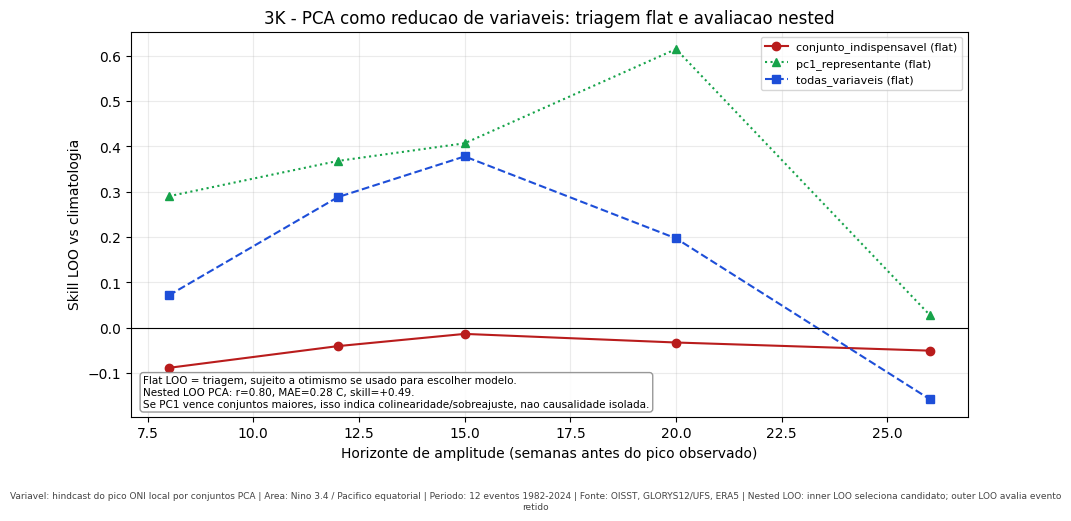

In [3]:
# Validacao preditiva do conjunto PCA: flat LOO como triagem + nested LOO como avaliacao defensavel.
# O objetivo do 3K nao e declarar previsao operacional; e testar se a reducao PCA perde ou nao sinal preditivo.
ev_h = u.events_noaa()
MINSET = list(ind['representante'])
FULLSET = [v for v in GROW if v != 'nino34_ssta']
HORIZ = [8, 12, 15, 20, 26]
rows = []
for H in HORIZ:
    for nome, vs in [('conjunto_indispensavel', MINSET), ('todas_variaveis', FULLSET), ('pc1_representante', [ind.iloc[0]['representante']])]:
        _, met = u.loo_peak_hindcast(w, ev_h, {v: H for v in vs})
        met.update({'modelo': nome, 'horizonte_sem': H, 'variaveis': '+'.join(vs)})
        rows.append(met)
val = pd.DataFrame(rows)[['modelo','horizonte_sem','variaveis','n_eventos','r_loo','mae_loo_c','mae_climatologia_c','skill_vs_climatologia']]
u.save_table(val, 'phase3K_previsao_pico_loo.csv', index=False)
print('Triagem flat LOO dos conjuntos PCA:')
print(val.to_string(index=False))

pca_candidates = []
for H in HORIZ:
    for nome, vs, racional in [
        ('pca_minimo', MINSET, 'representante de cada PC ate 90%'),
        ('pc1_representante', [ind.iloc[0]['representante']], 'representante do eixo dominante de recarga'),
        ('pca_completo_sem_ssta', FULLSET, 'todas variaveis de crescimento sem alvo'),
    ]:
        pca_candidates.append({
            'modelo': f'{nome}_{H}w', 'familia': nome, 'horizonte_sem': H,
            'variaveis': '+'.join(vs), 'n_preditores': len(vs), 'racional': racional,
            'spec': {v: H for v in vs},
        })
nested_pca_res, nested_pca_met, nested_pca_sel = u.nested_loo_peak_hindcast(w, ev_h, pca_candidates)
u.save_table(nested_pca_res, 'phase3K_previsao_pico_nested_loo_eventos.csv', index=False)
u.save_table(pd.DataFrame([nested_pca_met]), 'phase3K_previsao_pico_nested_loo_metricas.csv', index=False)
u.save_table(nested_pca_sel, 'phase3K_previsao_pico_nested_loo_selecao.csv', index=False)
print('\nNested LOO do protocolo PCA:')
print(pd.DataFrame([nested_pca_met]).T.to_string())

fig, ax = plt.subplots(figsize=(10.8, 5.0))
estilo = {'conjunto_indispensavel': ('#b91c1c', 'o-'), 'todas_variaveis': ('#1d4ed8', 's--'), 'pc1_representante': ('#16a34a', '^:')}
for nome, sub in val.groupby('modelo'):
    c, fmt = estilo.get(nome, ('#6b7280', 'o-'))
    ax.plot(sub['horizonte_sem'], sub['skill_vs_climatologia'], fmt, color=c, label=f'{nome} (flat)')
ax.axhline(0, color='k', lw=.8)
ax.set_xlabel('Horizonte de amplitude (semanas antes do pico observado)')
ax.set_ylabel('Skill LOO vs climatologia')
ax.set_title('3K - PCA como reducao de variaveis: triagem flat e avaliacao nested')
ax.legend(fontsize=8)
ax.grid(alpha=.25)
u.add_note(ax, f"Flat LOO = triagem, sujeito a otimismo se usado para escolher modelo.\nNested LOO PCA: r={nested_pca_met['r_nested_loo']:.2f}, MAE={nested_pca_met['mae_nested_loo_c']:.2f} C, skill={nested_pca_met['skill_vs_climatologia']:+.2f}.\nSe PC1 vence conjuntos maiores, isso indica colinearidade/sobreajuste, nao causalidade isolada.", loc='lower left')
u.stamp_caption(fig, variavel='hindcast do pico ONI local por conjuntos PCA', area='Nino 3.4 / Pacifico equatorial', periodo='12 eventos 1982-2024', fonte='OISST, GLORYS12/UFS, ERA5', extra='Nested LOO: inner LOO seleciona candidato; outer LOO avalia evento retido')
u.save_fig(fig, '3K1_skill_loo_nested.png')
plt.show()

[figura] data/processed/figures/fase3/3K2_scree.png


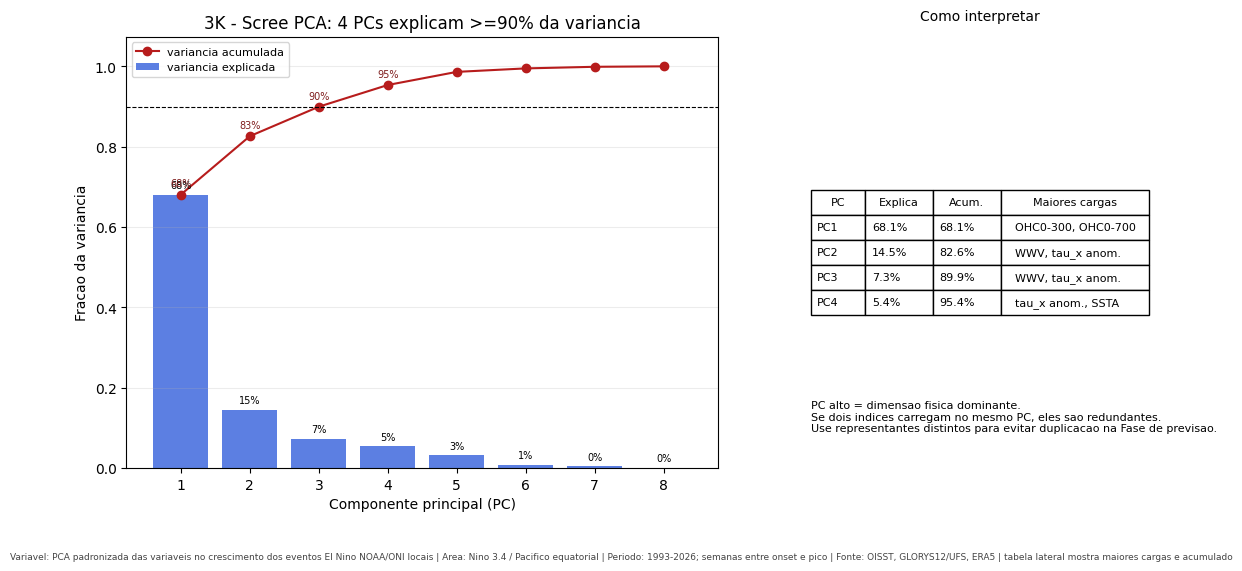

In [4]:
# Scree remodelado: barras, acumulado e tabela interpretativa ao lado.
fig, (ax, ax_tbl) = plt.subplots(1, 2, figsize=(13.2, 5.6), gridspec_kw={'width_ratios':[2.1, 1.2]})
x = np.arange(1, len(evr)+1)
ax.bar(x, evr, color='#1d4ed8', alpha=.72, label='variancia explicada')
ax.plot(x, evr.cumsum(), 'o-', color='#b71c1c', label='variancia acumulada')
ax.axhline(.9, ls='--', color='k', lw=.8)
for xi, val, cum in zip(x, evr, evr.cumsum()):
    ax.text(xi, val+0.015, f'{val*100:.0f}%', ha='center', fontsize=7)
    if xi <= max(n90, 3):
        ax.text(xi, cum+0.02, f'{cum*100:.0f}%', ha='center', fontsize=7, color='#7f1d1d')
ax.set_xlabel('Componente principal (PC)')
ax.set_ylabel('Fracao da variancia')
ax.set_ylim(0, min(1.08, max(1.0, evr.cumsum()[:max(n90,3)].max()+0.12)))
ax.legend(fontsize=8)
ax.set_title(f'3K - Scree PCA: {n90} PCs explicam >=90% da variancia')
ax.grid(axis='y', alpha=.24)
rows = []
for i in range(min(5, len(evr), len(load.columns))):
    pc = f'PC{i+1}'
    top = load[pc].abs().sort_values(ascending=False).head(2)
    rows.append([pc, f'{evr[i]*100:.1f}%', f'{evr[:i+1].sum()*100:.1f}%', ', '.join(u.var_label(v, short=True) for v in top.index)])
ax_tbl.axis('off')
tbl = ax_tbl.table(cellText=rows, colLabels=['PC','Explica','Acum.','Maiores cargas'], loc='center', cellLoc='left', colWidths=[.16,.2,.2,.44])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)
ax_tbl.set_title('Como interpretar', fontsize=10, pad=12)
ax_tbl.text(0, 0.08, 'PC alto = dimensao fisica dominante.\nSe dois indices carregam no mesmo PC, eles sao redundantes.\nUse representantes distintos para evitar duplicacao na Fase de previsao.', fontsize=8, va='bottom')
u.stamp_caption(fig, variavel='PCA padronizada das variaveis no crescimento dos eventos El Nino NOAA/ONI locais', area='Nino 3.4 / Pacifico equatorial', periodo='1993-2026; semanas entre onset e pico', fonte='OISST, GLORYS12/UFS, ERA5', extra='tabela lateral mostra maiores cargas e acumulado')
u.save_fig(fig, '3K2_scree.png')
plt.show()


[figura] data/processed/figures/fase3/3K3_biplot.png


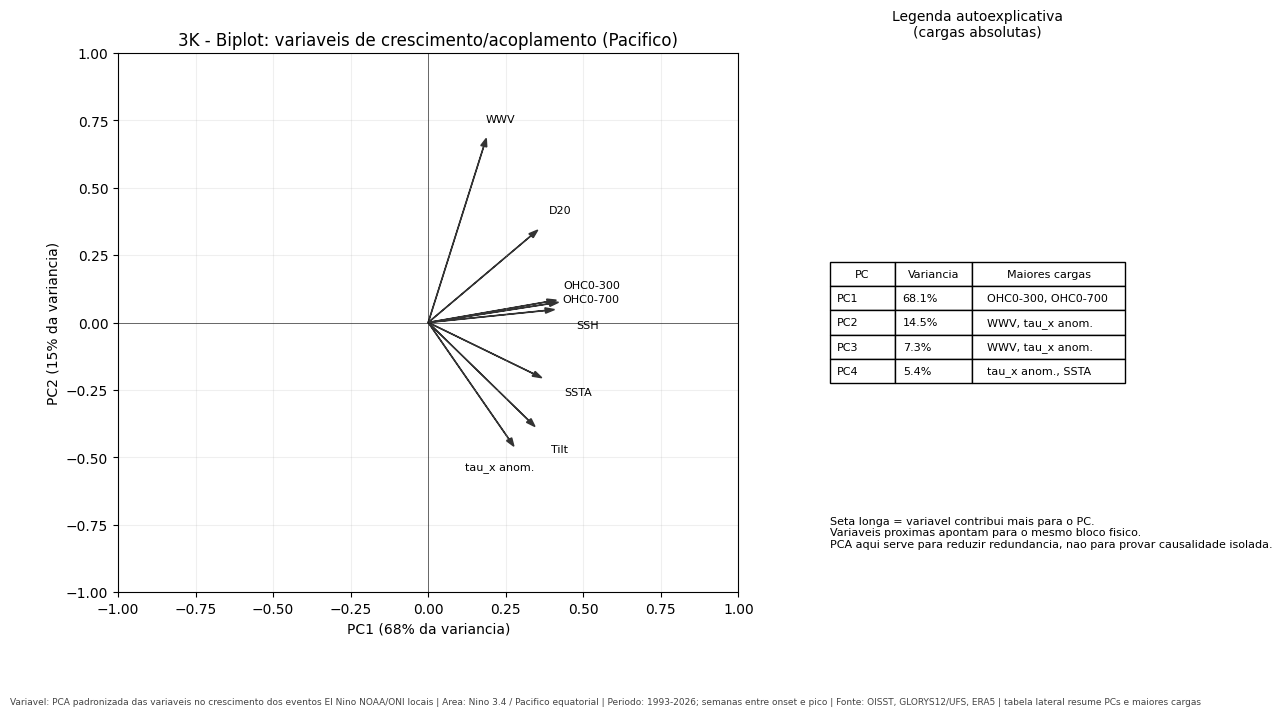

In [5]:
# biplot PC1xPC2 com tabela de leitura ao lado
fig,(ax,ax_tbl)=plt.subplots(1,2,figsize=(13,7),gridspec_kw={'width_ratios':[2.1,1]})
offsets={
    'nino34_ssta':(26,-10),'ohc_0_300':(24,12),'ohc_0_700':(25,1),
    'ssh_m':(24,-11),'tau_x_anom_nino34_pa':(-10,-16),'tilt_m':(18,-16),'wwv':(10,14),'d20_m':(16,14)
}
for v in Xdf.columns:
    x,y=load.loc[v,'PC1'],load.loc[v,'PC2']
    ax.arrow(0,0,x,y,head_width=.02,color='#333',length_includes_head=True)
    dx,dy=offsets.get(v,(8,8))
    ax.annotate(u.var_label(v,short=True),xy=(x,y),xytext=(dx,dy),textcoords='offset points',fontsize=8,ha='center',va='center')
ax.axhline(0,color='k',lw=.4); ax.axvline(0,color='k',lw=.4); ax.set_xlim(-1,1); ax.set_ylim(-1,1)
ax.set_xlabel(f'PC1 ({evr[0]*100:.0f}% da variancia)'); ax.set_ylabel(f'PC2 ({evr[1]*100:.0f}% da variancia)')
ax.set_title('3K - Biplot: variaveis de crescimento/acoplamento (Pacifico)')
ax.grid(alpha=.2)
ax_tbl.axis('off')
legend_rows=[]
for pc in [f'PC{i+1}' for i in range(min(n90,4))]:
    top=load[pc].abs().sort_values(ascending=False).head(2)
    legend_rows.append([pc, f"{evr[int(pc[2:])-1]*100:.1f}%", ', '.join(u.var_label(v,short=True) for v in top.index)])
table=ax_tbl.table(cellText=legend_rows,colLabels=['PC','Variancia','Maiores cargas'],loc='center',cellLoc='left',colWidths=[.22,.26,.52])
table.auto_set_font_size(False); table.set_fontsize(8); table.scale(1,1.45)
ax_tbl.set_title('Legenda autoexplicativa\n(cargas absolutas)',fontsize=10,pad=12)
ax_tbl.text(0,0.08,'Seta longa = variavel contribui mais para o PC.\nVariaveis proximas apontam para o mesmo bloco fisico.\nPCA aqui serve para reduzir redundancia, nao para provar causalidade isolada.',fontsize=8,va='bottom')
u.stamp_caption(fig,variavel='PCA padronizada das variaveis no crescimento dos eventos El Nino NOAA/ONI locais',area='Nino 3.4 / Pacifico equatorial',periodo='1993-2026; semanas entre onset e pico',fonte='OISST, GLORYS12/UFS, ERA5',extra='tabela lateral resume PCs e maiores cargas')
u.save_fig(fig,'3K3_biplot.png'); plt.show()

In [6]:
# Explicacao das variaveis por tras de cada PC (nao basta a % - importa QUEM carrega)
load_abs=load.abs()
print('Variancia:', ' '.join(f'PC{i+1}={evr[i]*100:.0f}%' for i in range(min(4,len(evr)))),
      f'| {n90} PCs = {evr[:n90].sum()*100:.0f}%')
print()
for pc in [f'PC{i+1}' for i in range(n90)]:
    top=load[pc].abs().sort_values(ascending=False).head(3)
    membros=', '.join(f'{v}({load.loc[v,pc]:+.2f})' for v in top.index)
    print(f'{pc} ({evr[int(pc[2:])-1]*100:.0f}% da variancia) dominado por: {membros}')
# tabela explicativa
rows=[]
for i,pc in enumerate([f'PC{k+1}' for k in range(n90)]):
    top=load[pc].abs().sort_values(ascending=False).head(3)
    rows.append({'PC':pc,'var_explicada_%':round(evr[i]*100,1),
                 'variaveis_dominantes':', '.join(top.index),
                 'loadings':', '.join(f'{load.loc[v,pc]:+.2f}' for v in top.index)})
expl=pd.DataFrame(rows); u.save_table(expl,'phase3K_pcs_explicados.csv',index=False); expl

Variancia: PC1=68% PC2=15% PC3=7% PC4=5% | 4 PCs = 95%

PC1 (68% da variancia) dominado por: ohc_0_300(+0.42), ohc_0_700(+0.41), ssh_m(+0.41)
PC2 (15% da variancia) dominado por: wwv(+0.68), tau_x_anom_nino34_pa(-0.46), tilt_m(-0.39)
PC3 (7% da variancia) dominado por: wwv(+0.65), tau_x_anom_nino34_pa(+0.52), d20_m(-0.38)
PC4 (5% da variancia) dominado por: tau_x_anom_nino34_pa(+0.62), nino34_ssta(-0.61), d20_m(+0.44)
[tabela] data/processed/parquet/statistics/phase3K_pcs_explicados.csv


,PC,var_explicada_%,variaveis_dominantes,loadings
0,PC1,68.1,"ohc_0_300, ohc_0_700, ssh_m","+0.42, +0.41, +0.41"
1,PC2,14.5,"wwv, tau_x_anom_nino34_pa, tilt_m","+0.68, -0.46, -0.39"
2,PC3,7.3,"wwv, tau_x_anom_nino34_pa, d20_m","+0.65, +0.52, -0.38"
3,PC4,5.4,"tau_x_anom_nino34_pa, nino34_ssta, d20_m","+0.62, -0.61, +0.44"


**Leitura do 3K.** PC1 concentra a maior parte da variancia e agrega D20/OHC/SSH/tilt: essas variaveis formam uma dimensao comum de **recarga/subsuperficie**. A validacao agora separa duas coisas: o `phase3K_previsao_pico_loo.csv` e triagem flat LOO dos conjuntos PCA, enquanto `phase3K_previsao_pico_nested_loo_metricas.csv` avalia a regra completa de escolher conjunto/horizonte dentro do treino e prever o evento retido. Se o representante do PC1 supera conjuntos maiores, a leitura correta e parcimonia/colinearidade com n pequeno, nao prova causal de uma unica variavel. O 3K informa a reducao fisica; o 3I usa candidatos fisicos pre-especificados e nested LOO para a projecao condicional. Escopo estritamente Pacifico.
